### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Importing Dataset

In [2]:
df = pd.read_csv('IMDb_updated.CSV')
df.head(10)

,Unnamed: 0,title,overview,original_language,vote_count,vote_average
0,0,Ad Astra,"The near future, a time when both hope and har...",en,2853,5.9
1,1,Bloodshot,"After he and his wife are murdered, marine Ray...",en,1349,7.2
2,2,Bad Boys for Life,Marcus and Mike are forced to confront new thr...,en,2530,7.1
3,3,Ant-Man,Armed with the astonishing ability to shrink i...,en,13611,7.1
4,4,Percy Jackson: Sea of Monsters,"In their quest to confront the ultimate evil, ...",en,3542,5.9
5,5,Birds of Prey (and the Fantabulous Emancipatio...,"Harley Quinn joins forces with a singer, an as...",en,2639,7.1
6,6,Live Free or Die Hard,"John McClane is back and badder than ever, and...",en,3714,6.5
7,7,Cold Blood,A legendary but retired hit man lives in peace...,fr,119,5.1
8,8,Underwater,After an earthquake destroys their underwater ...,en,584,6.5
9,9,The Platform,"A mysterious place, an indescribable prison, a...",es,1924,7.2


In [3]:
df.shape

(10000, 6)

In [4]:
df.dtypes

Unnamed: 0             int64
title                 object
overview              object
original_language     object
vote_count             int64
vote_average         float64
dtype: object

In [6]:
# Reimporting dataset with 'Unnamed: 0' as index column
df = pd.read_csv('IMDb_updated.CSV', index_col = 'Unnamed: 0')
df

,title,overview,original_language,vote_count,vote_average
0,Ad Astra,"The near future, a time when both hope and har...",en,2853,5.9
1,Bloodshot,"After he and his wife are murdered, marine Ray...",en,1349,7.2
2,Bad Boys for Life,Marcus and Mike are forced to confront new thr...,en,2530,7.1
3,Ant-Man,Armed with the astonishing ability to shrink i...,en,13611,7.1
4,Percy Jackson: Sea of Monsters,"In their quest to confront the ultimate evil, ...",en,3542,5.9
...,...,...,...,...,...
9995,Cargo,The story of CARGO takes place on rusty space-...,de,225,5.9
9996,The Good Night,"Gary, a musician, is trapped in an unhappy rel...",en,67,5.6
9997,The World Is Yours,"To escape his life of crime, a Paris drug deal...",fr,234,7.1
9998,The Grand Seduction,A small fishing village must procure a local d...,en,169,6.7


### Data Cleaning

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              10000 non-null  object 
 1   overview           9970 non-null   object 
 2   original_language  10000 non-null  object 
 3   vote_count         10000 non-null  int64  
 4   vote_average       10000 non-null  float64
dtypes: float64(1), int64(1), object(3)
memory usage: 468.8+ KB


In [8]:
# Checking for null values
pd.isnull(df).sum()

title                 0
overview             30
original_language     0
vote_count            0
vote_average          0
dtype: int64

In [9]:
# Replacing null values (to 'NA')
df['overview'].fillna('NA', inplace = True)

In [10]:
# Renaming column names 
df.rename(columns = {'overview': 'description'}, inplace = True)

In [11]:
df.columns

Index(['title', 'description', 'original_language', 'vote_count',
       'vote_average'],
      dtype='object')

In [12]:
df.duplicated().sum()

0

### Exporatory Data Analysis

#### Movie Ratings Distribution

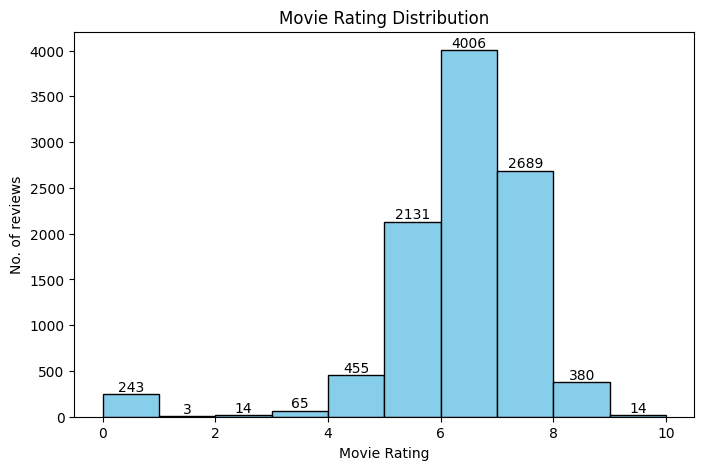

In [16]:
plt.figure(figsize = (8,5))
counts, bins, bars = plt.hist(df['vote_average'], color = 'skyblue', edgecolor = 'black')
plt.bar_label(bars)
plt.xlabel('Movie Rating')
plt.ylabel('No. of reviews')
plt.title('Movie Rating Distribution')
plt.show()

*Ratings between 6-7 occurs most frequently followed by 7-8 and 5-6\
Above is Left Skewed Histogram*

#### Most Popular Languages

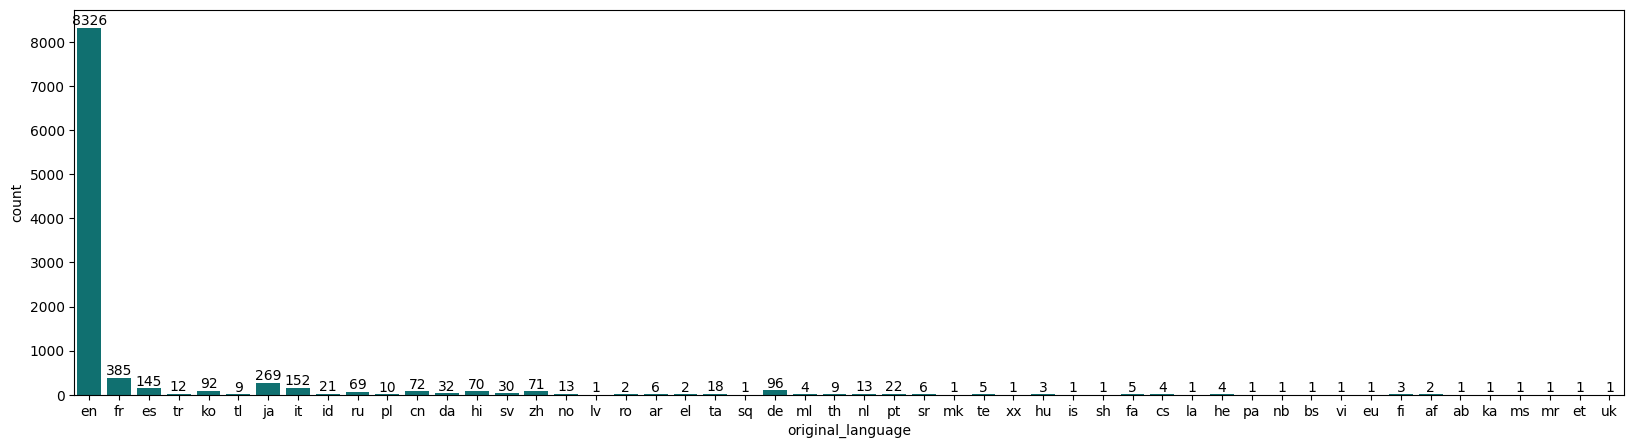

In [22]:
plt.figure(figsize = (20,5))
ax = sns.countplot(data = df, x = 'original_language', color = 'teal')

for bars in ax.containers:
    ax.bar_label(bars)

*English language movies are most popular ones followed by French and Japanese*

#### Language vs Rating

<Axes: xlabel='original_language', ylabel='vote_average'>

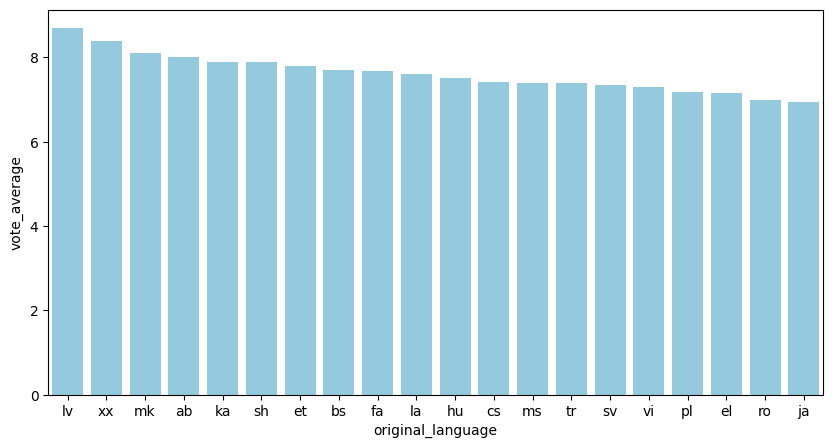

In [32]:
# Which languages have on an average highest-rated movies
lang_rat = df.groupby(['original_language'], as_index = False)['vote_average'].mean().sort_values('vote_average', ascending = False).head(20)

plt.figure(figsize = (10,5))
sns.barplot(data = lang_rat, x = 'original_language', y = 'vote_average', color = 'skyblue')

*Language 'lv' has on average highest rated movies followed by 'xx' and 'mk'*

#### Vote Count vs Rating

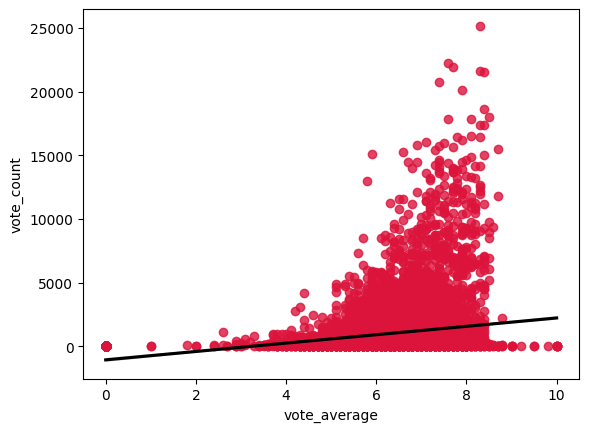

In [39]:
sns.regplot(data = df,
            x = 'vote_average',
            y = 'vote_count',
            scatter_kws = {'color' : 'crimson'},
            line_kws = {'color' : 'black'})
plt.show()

*Liner regression indicates that with increase in vote count, movie rating also increases but we cannot be sure because of overplotting*

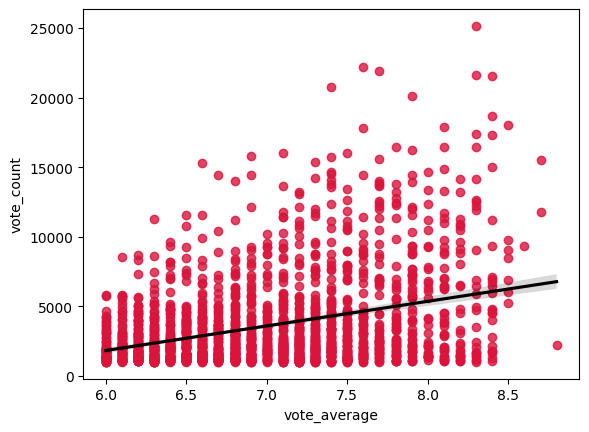

In [52]:
# Sampling of data to avoid overplotting
sns.regplot(data = df[(df['vote_average'] >= 6) & (df['vote_count'] >= 1000)],
            x = 'vote_average',
            y = 'vote_count',
            scatter_kws = {'color' : 'crimson'},
            line_kws = {'color' : 'black'})
plt.show()

#### Top Rated Movies

In [45]:
# With at least 1,000 votes

df[df['vote_count'] >= 1000].groupby(['title'], as_index = False)['vote_average'].sum().sort_values('vote_average', ascending = False)

,title,vote_average
228,Beauty and the Beast,20.5
730,Halloween,20.0
1389,Robin Hood,19.4
1910,The Lion King,15.4
1802,The Girl with the Dragon Tattoo,14.8
...,...,...
453,Death Note,4.2
886,Jack and Jill,4.1
1537,Son of the Mask,3.9
1481,Sharknado,3.8


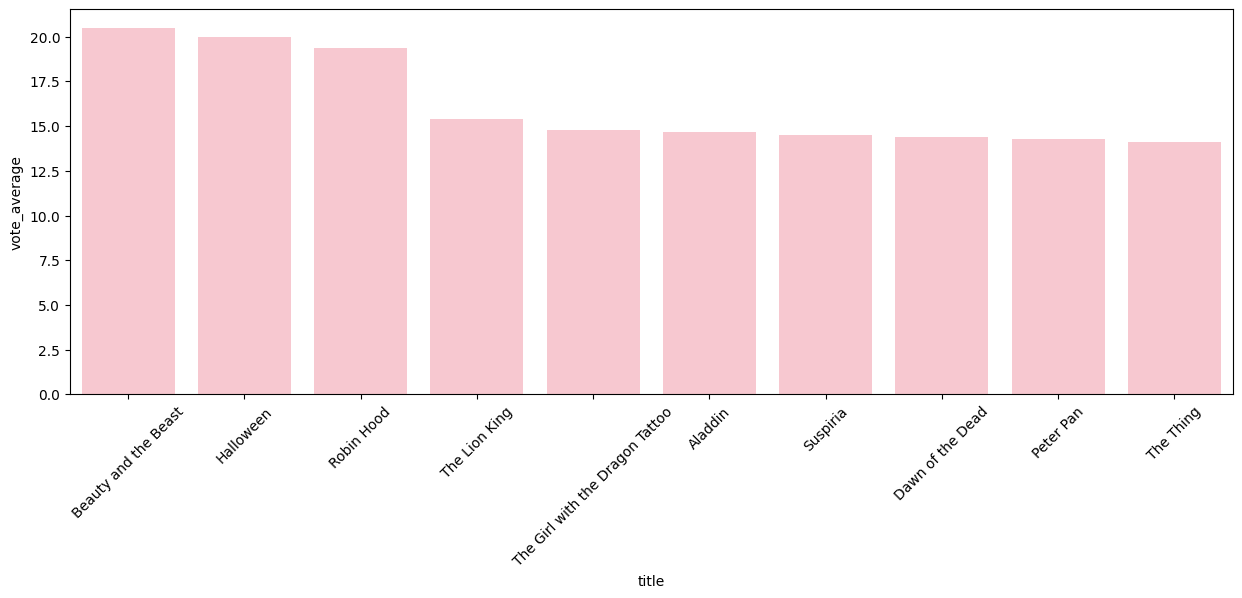

In [48]:
top_rated = df[df['vote_count'] >= 1000].groupby(['title'], as_index = False)['vote_average'].sum().sort_values('vote_average', ascending = False).head(10)

plt.figure(figsize = (15,5))
sns.barplot(data = top_rated, x = 'title', y = 'vote_average', color = 'pink')
plt.xticks(rotation = 45)
plt.show()

*For more than 1000 votes, 'Beauty and the Beast' is highest rated movie followed by 'Halloween' and 'Robin Hood'*

#### Most Voted Movies

In [53]:
# With at least 6 rating
df[df['vote_average'] >= 6].groupby(['title'], as_index = False)['vote_count'].sum().sort_values('vote_count', ascending = False)

,title,vote_count
2591,Inception,25148
1394,Deadpool,22225
5024,The Avengers,21893
2633,Interstellar,21589
5228,The Dark Knight,21561
...,...,...
2209,Gully,1
3082,Locusts,1
2216,HADES,1
397,And What Is He Like?,1


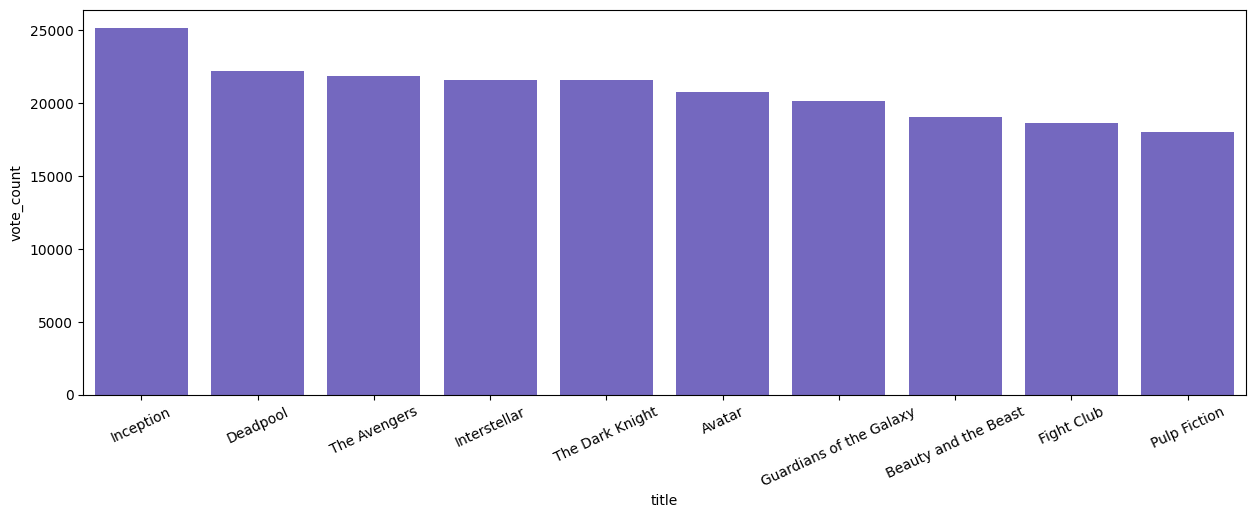

In [56]:
most_voted = df[df['vote_average'] >= 6].groupby(['title'], as_index = False)['vote_count'].sum().sort_values('vote_count', ascending = False).head(10)

plt.figure(figsize = (15,5))
sns.barplot(data = most_voted, x = 'title', y = 'vote_count', color = 'slateblue')
plt.xticks(rotation = 25)
plt.show()

*For movies wih ratings greater than 6, 'Inception' is most voted movie followed by 'Deadpool' and 'The Avengers'*